# Molecular dynamics simulations of a Lennard-Jones-like liquid

In a classical approximation, interactions between atoms consist of a repulsive term due to electron shell overlap and an attractive term due to dipole-dipole interactions. These terms are typically parametrized by the Lennard-Jones potential. For computational convenience, we use the Wang-Frenkel interaction potential between particles $i$ and $j$ instead


$$
U_{ij}^{\mathrm{WF}} =
\begin{cases}
\epsilon \left[ \left( \frac{\sigma}{r_{ij}} \right)^2 - 1 \right]
\left[ \left( \frac{r_c}{r_{ij}} \right)^2 - 1 \right]^2 & \text{if } r_{ij} < r_c \\
0 & \text{otherwise.}
\end{cases}
$$

with $\sigma$ and $\epsilon$ being phenomenological constants and $r_c$ being the cutoff distance. The distance between molecules is denoted $r_{ij}$. We consider a two-dimensional system of spherical molecules with periodic boundary conditions. The molecules all have the same mass $m$.

## 1. Initialization

### (a)

Write a script to generate the positions of a two-dimensional system of molecules with a packing fraction $\phi$, which is defined as

$$
\phi = \frac{N \pi \sigma^2}{A},
$$
with $N$ being the number of molecules and $A$ being the total surface area of
two-dimensional system. Make sure that the molecules do not overlap because
that would lead to very large energies

In [38]:
#1a
import numpy as np
import matplotlib.pyplot as plt 

#Constants
rc = 1.0
sigma = 1.0
epsilon = 1.0
phi = 0.5

#Parameter
N = 100

#function to generate positions with the given tensity 
def generate_positions(N, phi, sigma, factor = 1.0, max_trials=100000):
    positions = []
    cnt = 0

    #calculate A for the chosen N and sigma
    A = (N*np.pi*sigma**2) / phi 

    #quadradic field with sidelenght L
    L = np.sqrt(A)

    #calc minimal distance between two moleculecenters
    min_distance = 2* sigma * factor

    #try as long as their are N molecules or max_tails is reached
    while len(positions) < N and cnt < max_trials:
        p = np.array([np.random.uniform(0, L),
                      np.random.uniform(0, L)])

        # check if their is an overlap
        ok = True
        for q in positions:
            if np.linalg.norm(p - q) < min_distance:
                ok = False
                break

        if ok:
            positions.append(p)

        cnt += 1

    # if the number of paricles cannot be reached within the max 
    # nuber of trails stopp with the error 
    if len(positions) < N:
        raise RuntimeError("density not reachable.")

    return np.array(positions), L


positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)

print("Box length L =", L)
print("Generated positions:")
print(positions)



Box length L = 25.066282746310005
Generated positions:
[[2.05232931e+01 2.21558293e+01]
 [1.97085317e+00 1.14403246e+00]
 [2.37824132e+01 1.00388193e+01]
 [7.37697453e+00 2.37880935e+01]
 [2.49093914e+01 1.89742678e+01]
 [3.19480615e+00 2.04227025e+01]
 [2.17462334e+01 2.11245595e-01]
 [2.42535244e+01 5.74808211e-01]
 [1.18813906e+00 3.84719928e+00]
 [1.29856362e+01 7.96442807e+00]
 [8.71851336e+00 1.41664147e+01]
 [2.43216819e+01 4.43654153e+00]
 [1.70735070e+01 5.18309479e-01]
 [2.12054602e+01 5.00616826e+00]
 [1.85047854e+01 2.05634530e+01]
 [3.59717953e+00 1.06534250e+01]
 [3.19820974e+00 3.31142807e+00]
 [1.00975934e+00 1.79231370e+01]
 [1.82221978e+01 3.11935911e+00]
 [2.31762172e+01 1.65105120e+01]
 [6.11777243e+00 1.05200472e+01]
 [1.36580010e+01 2.25637977e+01]
 [1.57552170e+01 1.72498986e+01]
 [1.41813521e+01 1.07211769e+01]
 [8.35551389e+00 1.87858138e+01]
 [1.44147854e+01 5.85259860e+00]
 [2.45569445e+00 1.42124480e+01]
 [6.41241759e+00 2.72627220e+00]
 [1.75370934e+01 7.15

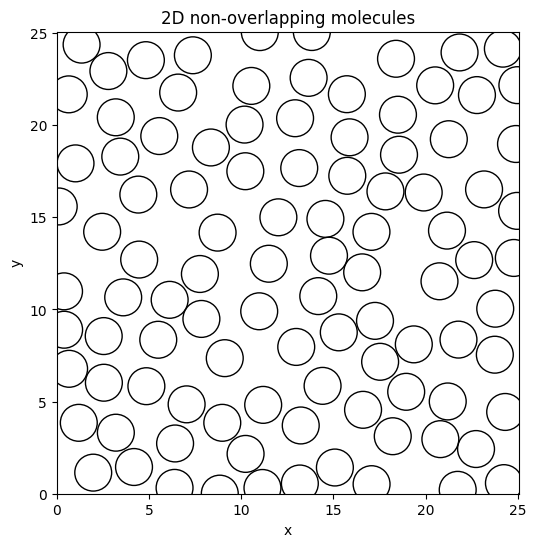

In [39]:
#Testfeld
# plot -> plot particles
fig, ax = plt.subplots(figsize=(6, 6))

for x, y in positions:
    circle = plt.Circle((x, y), sigma, fill=False)
    ax.add_patch(circle)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D non-overlapping molecules")
plt.show()

(b) Generate initial velocities for all particles by drawing independent velocities
in every dimension from a Gaussian distribution corresponding to an initial
temperature $T$ . Make sure that the velocity of the center of mass of the system
vanishes.

In [40]:
#1b
# function to generate the velocities
def generate_velocities(N, T, k_B, m):
    # for corresbondig to a Temp use a sigma_v(T)
    # Äquipartitionstheorem 1/2 kb T per dimension
    sigma_v = np.sqrt(k_B*T/m)
    # create velocities
    v = np.random.normal(0.0, sigma_v, size=(N, 2))

    # subtract center-of-mass velocity
    v_cm = np.mean(v, axis=0)
    v_cm_corr = v - v_cm

    return v, v_cm_corr 

# check the function (vanishes v of des center of mass)
N = 1000
m =1.0
k_B = 1.0
T = 1.0

v, v_cm_corr = generate_velocities(N, T, k_B, m)
print("Number of Values", np.shape(v))
print("Means of  direction (without COM correction):", np.mean(v, axis=0))
print("Means of  direction (with COM correction):", np.mean(v_cm_corr, axis=0))
#print(positions)


Number of Values (1000, 2)
Means of  direction (without COM correction): [-0.03840567  0.04785786]
Means of  direction (with COM correction): [-2.44249065e-17  5.44009282e-18]


2 Force calculation
The force between the molecules is given as usual by $f_{ij} = −\nabla U^{WF}_{ij}$ . The forces
are assumed to be pairwise additive.

    (a) Write a script to calculate the force on all particles from the positions of the
particles. Take care that periodic boundary conditions are used.

In [53]:
#2a
def pair_force(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)
    return f 

# test the function
#rc = 10
#i = 0
#j = 6
#rij = positions[i]-positions[j]
#r = np.linalg.norm(rij)
#f = pair_force(rij, epsilon, sigma, rc)
#print(rij)
#print(r)
#print(f)
#print(positions)

# vectorization possible?
def total_forces(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)

    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij = pair_force(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij
    return forces

# Test of te funciton
rc = 10
f_tot = total_forces(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])


25.066282746310005
[[ 3.47132524e+02  2.36717135e+02]
 [ 1.26632772e+02 -4.50505754e+02]
 [ 1.14425438e+03 -1.54718854e+02]
 [-2.50953000e+02  8.62636473e+02]
 [ 1.19299765e+03 -9.65631026e+02]
 [ 5.04369841e+01 -3.10589809e+02]
 [ 6.26216297e+02 -1.25051989e+03]
 [-2.34306010e+02 -1.71946419e+03]
 [ 7.29259618e+01  1.78371056e+02]
 [ 3.55482516e+02  6.56911012e+01]
 [-9.39816494e+01 -1.57152114e+02]
 [ 5.59957625e+02 -1.77011756e+02]
 [-3.14050530e+02  5.26530496e+01]
 [-4.00945045e+02 -5.44138264e+02]
 [ 6.83639569e+01 -3.58353862e+02]
 [ 2.36716599e+02  3.88978567e+00]
 [-3.94767085e+02 -3.82345527e+02]
 [-1.06072136e+03  7.48523118e+02]
 [-1.46350724e+02  4.93251144e+02]
 [ 9.04276030e+02 -4.79731254e+02]
 [ 5.26907053e+02 -3.20010655e+02]
 [ 1.62802412e+02 -1.38365403e+02]
 [ 2.84868233e+02  2.68104602e+02]
 [ 3.99183077e+02  4.43702042e+01]
 [ 4.99291747e+02 -9.85976109e+01]
 [-1.60750015e+01 -8.37252595e+01]
 [-1.00096406e+02  4.26727575e+01]
 [ 2.38066985e+01  6.72191746e+01]
 

    (b) Include a calculation of the total potential energy of the system in the calculation
of the forces.

In [42]:
#2b

(c) Evaluate the scaling of computational cost of the force calculation with the num-
ber of particles $N$ .

In [43]:
#2c

3 Integration of the equations of motion

(a)

Nondimensionalize the equations and pick a sensible time step in terms of $\sigma$, $\epsilon$ and the particle mass $m$.

The velocity-Verlet algorithm for positions $r$, velocities $v$ and forces $f$ consists of the following steps:

$$
v\left(t + \frac{\Delta t}{2}\right) = v(t) + \frac{f(t)}{2m}\Delta t
$$

$$
r(t + \Delta t) = r(t) + v\left(t + \frac{\Delta t}{2}\right)\Delta t
$$

$$
f(t + \Delta t) = f(r(t + \Delta t))
$$

$$
v(t + \Delta t) = v\left(t + \frac{\Delta t}{2}\right) + \frac{f(t+\Delta t)}{2m}\Delta t
$$


In [44]:
#3a

(b)

Implement the velocity-Verlet algorithm to solve the equations of motion.

In [45]:
#3b

(c)

Calculate the kinetic energy at every integer time step and plot the total energy and the temperature as a function of time.

In [46]:
#3c
